<a href="https://colab.research.google.com/github/Aarush112-dev/dlesson1/blob/main/Auto_encoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import tensorflow
import keras
from tensorflow.keras import models
import tensorflow.keras.layers as layers
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train = x_train.astype("float32")/255
x_test = x_test.astype("float32")/255

In [ ]:
x_train = x_train.reshape((-1, 28, 28))
x_test = x_train.reshape((-1, 28, 28))

In [ ]:
noise_factor = 0.5
noisy_x_train = x_train + noise_factor * np.random.normal(loc=0, scale=1, size=x_train.shape)
noisy_x_test = x_test + noise_factor * np.random.normal(loc=0, scale=1, size=x_test.shape)
noise_x_train = np.clip(noisy_x_train, 0., 1.)
noise_x_test = np.clip(noisy_x_test, 0., 1.)

In [ ]:
encoder_input = layers.Input(shape=(28,28))
print(encoder_input)

<KerasTensor shape=(None, 28, 28), dtype=float32, sparse=False, ragged=False, name=keras_tensor>


In [ ]:
encoder = LSTM(units=128, activation= "relu", return_state=True, name="encoder")(encoder_input)
print(encoder)

(<KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>, <KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2>, <KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_3>)


In [ ]:
encoder_state = encoder[1]
encoder_model = models.Model(encoder_input, outputs=encoder_state)

In [ ]:
from flax.nnx.nn.recurrent import Output
decoder_input = layers.Input(shape=(128,))
decoder = layers.RepeatVector(28)(decoder_input)
decoder = LSTM(units=128, activation="relu", return_sequences=True)(decoder)
Output = layers.TimeDistributed(layers.Dense(units=28, activation="sigmoid"))(decoder)
decoder_model = models.Model(decoder_input, outputs=Output)

In [ ]:
autoencoder = models.Model(encoder_input, decoder_model(encoder_model(encoder_input)))
autoencoder.compile(optimizer="adam",metrics=["accuracy"], loss="binary_crossentropy")
autoencoder.fit(noisy_x_train, x_train, epochs=10, batch_size=128, shuffle=True, validation_data=(noisy_x_test, x_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 133s 274ms/step - accuracy: 0.0701 - loss: 0.3719 - val_accuracy: 0.0896 - val_loss: 0.3182
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 127s 242ms/step - accuracy: 0.0965 - loss: 0.3123 - val_accuracy: 0.1042 - val_loss: 0.3081
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 114s 244ms/step - accuracy: 0.1101 - loss: 0.3047 - val_accuracy: 0.1258 - val_loss: 0.3013
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 244ms/step - accuracy: 0.1223 - loss: 0.3006 - val_accuracy: 0.1228 - val_loss: 0.2996
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 242ms/step - accuracy: 0.1317 - loss: 0.2980 - val_accuracy: 0.1413 - val_loss: 0.2973
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 114s 242ms/step - accuracy: 0.1398 - loss: 0.2955 - val_accuracy: 0.1437 - val_loss: 0.2961
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 242ms/step - accuracy: 0.1458 - loss: 0.2943 - val_accuracy: 0.1510 - val_loss: 0.2953
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 114s 242ms/step - accuracy: 0.1494 -

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step


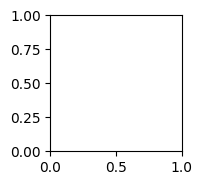

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

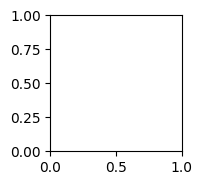

In [ ]:
encoded_images = encoder_model.predict(x_test)
decoded_images = autoencoder.predict(noisy_x_test)
n = 10
from matplotlib import pyplot as plt
plt.figure(figsize=(20, 6))
for i in range(n):
  ax = plt.subplot(3, n, i+1)
  plt.show(x_test[i])
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
  ax = plt.subplot(3, n, i+1+n)
  plt.show(encoded_images[i].reshape(128,1))
  plt.gray()
  ax = plt.subplot(3, n, i+1+2*n)
  plt.show(decoded_images[i])
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()